In [1]:
PREDICTION_INPUT_LENGTH = 30
PREDICTION_OUTPUT_LENGTH = 7

In [2]:
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

In [3]:
# Load data from csv file
data_appl = pd.read_csv('http://picoshare.cung.io.vn/-dUS4CA39aU')

In [4]:
data_msft = pd.read_csv('https://picoshare.cung.io.vn/-gYKvMG6mrs')
data_acb = pd.read_csv('https://picoshare.cung.io.vn/-bXEEcU67FF')

In [5]:
# Show some first data samples
data_appl.head()

,low,high,open,close,volume,year,days,month_sin,month_cos,day_sin,day_cos,weekday_sin,weekday_cos
0,-0.053581,-0.053343,-0.049004,-0.053581,-0.980845,0.166667,0.179586,-2.449294e-16,1.0,0.101168,-0.994869,0.781831,0.623490
1,-0.076231,-0.075869,-0.075869,-0.076231,-0.508959,0.166667,0.179631,-2.449294e-16,1.0,-0.101168,-0.994869,0.974928,-0.222521
2,0.024450,0.024331,0.019512,0.024450,-0.201401,0.166667,0.179676,-2.449294e-16,1.0,-0.299363,-0.954139,0.433884,-0.900969
3,0.028580,0.028445,0.028580,0.028580,-0.162870,0.166667,0.179721,-2.449294e-16,1.0,-0.485302,-0.874347,-0.433884,-0.900969
4,0.059239,0.058970,0.059239,0.059239,-0.412351,0.166667,0.179766,-2.449294e-16,1.0,-0.651372,-0.758758,-0.974928,-0.222521


In [6]:
# Get some info about the data
data_appl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10589 entries, 0 to 10588
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   low          10589 non-null  float64
 1   high         10589 non-null  float64
 2   open         10589 non-null  float64
 3   close        10589 non-null  float64
 4   volume       10589 non-null  float64
 5   year         10589 non-null  float64
 6   days         10589 non-null  float64
 7   month_sin    10589 non-null  float64
 8   month_cos    10589 non-null  float64
 9   day_sin      10589 non-null  float64
 10  day_cos      10589 non-null  float64
 11  weekday_sin  10589 non-null  float64
 12  weekday_cos  10589 non-null  float64
dtypes: float64(13)
memory usage: 1.1 MB


In [7]:
# Split the dataset into time windows to get data samples.

df = data_appl.clip(-1, 1)

cols_to_scale = ['volume', 'year', 'days', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'weekday_sin', 'weekday_cos']
scale_factor = 0.001
df = (
    data_appl.clip(-1, 1)  # First clip (original range)
    .assign(**{c: lambda d, c=c: d[c] * scale_factor for c in cols_to_scale}) # Multiply
    .clip(-1, 1)  # Final output clip
)

split_points = [0.005, 0.02]
full_split_points = [-i for i in split_points][::-1] + split_points
thresholds = np.array(full_split_points)
n_classes = len(full_split_points) + 1
bucket_ends = ['-inf'] + [f'{i:.3f}' for i in full_split_points] + ['inf']
bucket_names = [f'{bucket_ends[i]} -> {bucket_ends[i + 1]}' for i in range(n_classes)]


X_data = []
Y_data = []
feature_count = len(df.keys())
window_input = PREDICTION_INPUT_LENGTH
window_output = PREDICTION_OUTPUT_LENGTH

shape_input = (window_input, feature_count)
shape_output = (window_output, n_classes)

model_input_length = window_input * feature_count

for i in range(len(df) - window_input - window_output):
    # Slice the features (X)
    data_input = df.iloc[i : i + window_input].values
    # Slice the target 'open' values (Y)
    raw_y = df.iloc[i + window_input : i + window_input + window_output, 2].values
    # Map to buckets (0 to 4)
    bucketed = np.digitize(raw_y, thresholds)
    data_output = keras.utils.to_categorical(bucketed, num_classes=n_classes)
    # Convert to one-hot (7, 5) and append
    X_data.append(data_input)
    Y_data.append(data_output)

X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"X shape: {X_data.shape}") # (Samples, 30, Features)
print(f"Y shape: {Y_data.shape}") # (Samples, 7, 5)

X shape: (10552, 30, 13)
Y shape: (10552, 7, 5)


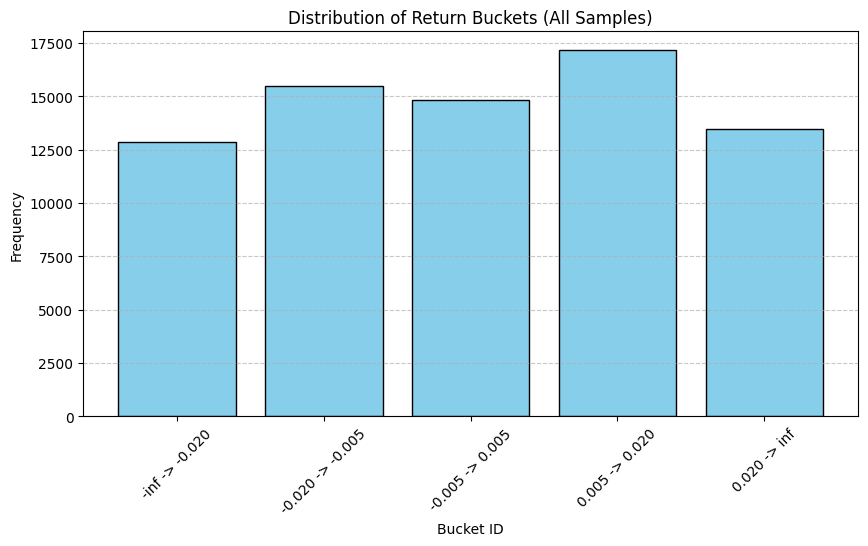

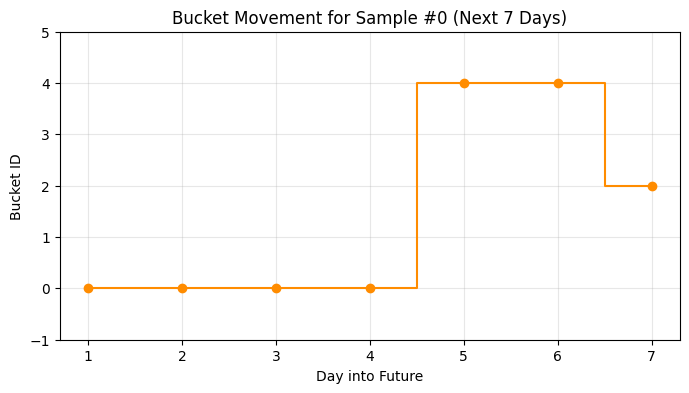

In [8]:
# --- 1. Distribution Plot ---
# We flatten Y to see the total count of every bucket across the whole dataset
y_integers = np.argmax(Y_data, axis=-1).flatten()

plt.figure(figsize=(10, 5))
counts = np.bincount(y_integers, minlength=n_classes)
plt.bar(range(n_classes), counts, color='skyblue', edgecolor='black')
plt.title("Distribution of Return Buckets (All Samples)")
plt.xlabel("Bucket ID")
plt.ylabel("Frequency")
plt.xticks(range(n_classes), bucket_names, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 2. Movement Plot ---
# Visualizing the 'movement' of buckets for the first sample in your dataset
sample_idx = 0
sample_movement = np.argmax(Y_data[sample_idx], axis=-1)

plt.figure(figsize=(8, 4))
plt.step(range(1, 8), sample_movement, where='mid', marker='o', color='darkorange')
plt.title(f"Bucket Movement for Sample #{sample_idx} (Next 7 Days)")
plt.xlabel("Day into Future")
plt.ylabel("Bucket ID")
plt.locator_params(axis='y', integer=True)
plt.ylim(-1, n_classes)
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Split the data into training, validation and test set

X_trainval, X_test, Y_trainval, Y_test = sklearn.model_selection.train_test_split(X_data, Y_data, test_size=0.2, shuffle=False)
X_train, X_val, Y_train, Y_val = sklearn.model_selection.train_test_split(X_trainval, Y_trainval, test_size=0.2, shuffle=False)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
Y_train = np.array(Y_train)
Y_val = np.array(Y_val)
Y_test = np.array(Y_test)

# Print shape of the training, validation and test set
print("Shape of training set: ", X_train.shape, Y_train.shape)
print("Shape of validation set: ", X_val.shape, Y_val.shape)
print("Shape of test set: ", X_test.shape, Y_test.shape)

Shape of training set:  (6752, 30, 13) (6752, 7, 5)
Shape of validation set:  (1689, 30, 13) (1689, 7, 5)
Shape of test set:  (2111, 30, 13) (2111, 7, 5)


In [10]:
def balance_sequence_data(X, y):
    # 1. Identify the class of the FIRST day (index 0) for every sample
    # y shape is (samples, 7, 3), so we look at (samples, 0, :)
    first_day_labels = np.argmax(y[:, 0, :], axis=1)

    # 2. Count occurrences
    unique_classes, counts = np.unique(first_day_labels, return_counts=True)
    min_samples = np.min(counts)

    print(f"Original distribution: {dict(zip(unique_classes, counts))}")
    print(f"Targeting {min_samples} samples per class.")

    balanced_indices = []

    # 3. Randomly undersample each class to match the minority count
    for cls in unique_classes:
        cls_indices = np.where(first_day_labels == cls)[0]
        # Choose a random subset of indices for this class
        chosen = np.random.choice(cls_indices, min_samples, replace=False)
        balanced_indices.extend(chosen)

    # 4. Shuffle so classes are mixed during training
    np.random.shuffle(balanced_indices)

    return X[balanced_indices], y[balanced_indices]

# Apply only to training data
X_train, Y_train = balance_sequence_data(X_train, Y_train)

print("New training shape:", X_train.shape, Y_train.shape) # Should be (min_samples * 3, 30, 13)

Original distribution: {np.int64(0): np.int64(1397), np.int64(1): np.int64(1399), np.int64(2): np.int64(1119), np.int64(3): np.int64(1386), np.int64(4): np.int64(1451)}
Targeting 1119 samples per class.
New training shape: (5595, 30, 13) (5595, 7, 5)


In [11]:
import keras.layers as layers

keras.backend.clear_session()
model = keras.Sequential(name='Model')
model.add(layers.Input(shape=shape_input))

# --- ENCODER ---
model.add(layers.LSTM(100, activation='tanh', return_sequences=True))
model.add(layers.BatchNormalization()) # Stabilize the first layer output
model.add(layers.Dropout(0.2))

model.add(layers.LSTM(100, activation='tanh', return_sequences=False))
model.add(layers.BatchNormalization()) # Stabilize the summary vector
model.add(layers.Dropout(0.2))

# --- BRIDGE ---
model.add(layers.RepeatVector(window_output))

# --- DECODER ---
model.add(layers.LSTM(100, activation='tanh', return_sequences=True))
model.add(layers.BatchNormalization()) # Stabilize the sequence generation
model.add(layers.Dropout(0.2))

# --- OUTPUT ---
model.add(layers.TimeDistributed(layers.Dense(n_classes, activation='softmax')))

model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 7, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 7, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 100)         │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 7, 5)           │           505 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,105 (812.91 KB)

 Trainable params: 207,505 (810.57 KB)

 Non-trainable params: 600 (2.34 KB)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=16,
    shuffle=True,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            min_delta=0.0001,
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            min_delta=0.0001,
            patience=10,
            restore_best_weights=True,
        ),
    ]
)

Epoch 1/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.2077 - loss: 1.7269 - val_accuracy: 0.2640 - val_loss: 1.5884 - learning_rate: 0.0020
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.2275 - loss: 1.6215 - val_accuracy: 0.2703 - val_loss: 1.5874 - learning_rate: 0.0020
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2507 - loss: 1.5824 - val_accuracy: 0.1597 - val_loss: 1.6556 - learning_rate: 0.0020
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2637 - loss: 1.5535 - val_accuracy: 0.1515 - val_loss: 1.7514 - learning_rate: 0.0020
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.2695 - loss: 1.5423 - val_accuracy: 0.1709 - val_loss: 1.6706 - learning_rate: 0.0020
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2756 - loss: 1.5316 - val_accuracy: 0.1417 - val_loss: 1.9951 - learning_rate: 0.0010
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2764 - loss: 

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Classification Report:

                  precision    recall  f1-score   support

  -inf -> -0.020       0.69      0.50      0.58       205
-0.020 -> -0.005       0.55      0.49      0.52       450
 -0.005 -> 0.005       0.55      0.62      0.58       615
  0.005 -> 0.020       0.60      0.73      0.66       613
    0.020 -> inf       0.80      0.48      0.60       228

        accuracy                           0.60      2111
       macro avg       0.64      0.56      0.59      2111
    weighted avg       0.61      0.60      0.59      2111



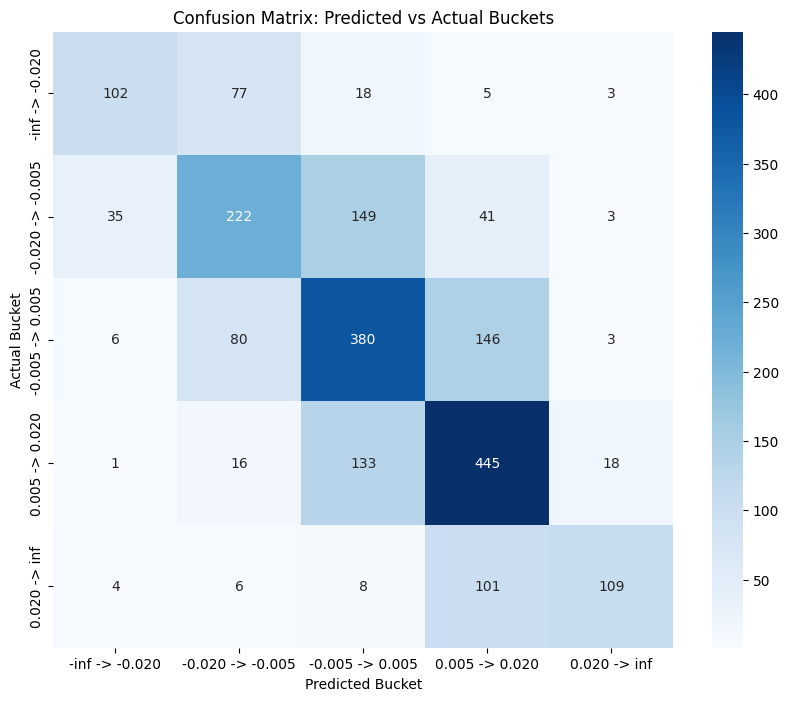

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get predictions (shape: Samples, 7, 7)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities and true labels to integer classes
# We flatten them to treat every 'predicted day' as an individual sample
# y_pred_classes = np.argmax(y_pred_probs, axis=-1).flatten()
# y_true_classes = np.argmax(Y_test, axis=-1).flatten()
y_pred_classes = np.argmax(y_pred_probs, axis=-1)[:,0]
y_true_classes = np.argmax(Y_test, axis=-1)[:,0]

# 3. Generate Classification Report
# This shows Precision, Recall, and F1-Score for each of your 7 buckets
# bucket_names = ['Strong Down', 'Down', 'Slight Down', 'Flat', 'Slight Up', 'Up', 'Strong Up']
print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=bucket_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bucket_names, yticklabels=bucket_names)
plt.title('Confusion Matrix: Predicted vs Actual Buckets')
plt.ylabel('Actual Bucket')
plt.xlabel('Predicted Bucket')
plt.show()

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:

                  precision    recall  f1-score   support

  -inf -> -0.020       0.37      0.11      0.17      1432
-0.020 -> -0.005       0.45      0.09      0.15      3151
 -0.005 -> 0.005       0.41      0.14      0.21      4309
  0.005 -> 0.020       0.31      0.84      0.46      4289
    0.020 -> inf       0.35      0.17      0.23      1596

        accuracy                           0.33     14777
       macro avg       0.38      0.27      0.24     14777
    weighted avg       0.38      0.33      0.27     14777



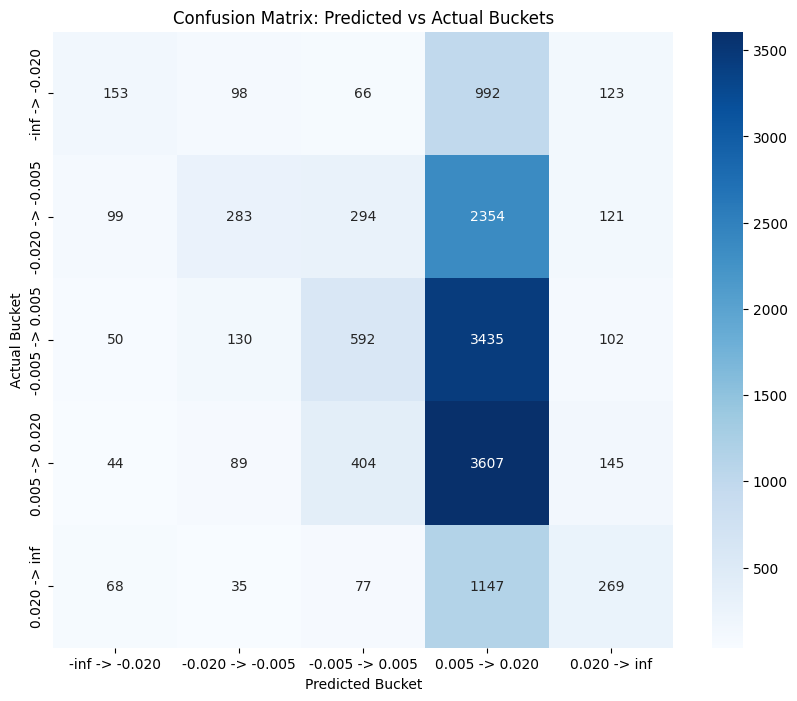

In [15]:
# 1. Get predictions (shape: Samples, 7, 7)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities and true labels to integer classes
# We flatten them to treat every 'predicted day' as an individual sample
y_pred_classes = np.argmax(y_pred_probs, axis=-1).flatten()
y_true_classes = np.argmax(Y_test, axis=-1).flatten()

# 3. Generate Classification Report
# This shows Precision, Recall, and F1-Score for each of your 7 buckets
# bucket_names = ['Strong Down', 'Down', 'Slight Down', 'Flat', 'Slight Up', 'Up', 'Strong Up']
print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=bucket_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bucket_names, yticklabels=bucket_names)
plt.title('Confusion Matrix: Predicted vs Actual Buckets')
plt.ylabel('Actual Bucket')
plt.xlabel('Predicted Bucket')
plt.show()

In [16]:
data_msft.head()

,low,high,open,close,volume,year,days,month_sin,month_cos,day_sin,day_cos,weekday_sin,weekday_cos
0,0.093520,0.008510,0.093520,0.035089,-1.208430,0.266667,0.265542,1.0,6.123234e-17,0.299363,-0.954139,-0.974928,-0.222521
1,0.035089,0.008438,0.035089,0.017103,-0.838984,0.266667,0.265676,1.0,6.123234e-17,-0.299363,-0.954139,0.781831,0.623490
2,-0.017391,0.000000,0.017103,-0.025761,-0.675569,0.266667,0.265721,1.0,6.123234e-17,-0.485302,-0.874347,0.974928,-0.222521
3,-0.017698,-0.025541,-0.025761,-0.017543,-0.347068,0.266667,0.265766,1.0,6.123234e-17,-0.651372,-0.758758,0.433884,-0.900969
4,-0.027149,-0.026201,-0.017543,-0.026906,0.198920,0.266667,0.265811,1.0,6.123234e-17,-0.790776,-0.612106,-0.433884,-0.900969


In [17]:
data_msft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9263 entries, 0 to 9262
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   low          9263 non-null   float64
 1   high         9263 non-null   float64
 2   open         9263 non-null   float64
 3   close        9263 non-null   float64
 4   volume       9263 non-null   float64
 5   year         9263 non-null   float64
 6   days         9263 non-null   float64
 7   month_sin    9263 non-null   float64
 8   month_cos    9263 non-null   float64
 9   day_sin      9263 non-null   float64
 10  day_cos      9263 non-null   float64
 11  weekday_sin  9263 non-null   float64
 12  weekday_cos  9263 non-null   float64
dtypes: float64(13)
memory usage: 940.9 KB


In [18]:
# Split the dataset into time windows to get data samples.

msft_scale_factor = scale_factor
df_msft = (
    data_msft.clip(-1, 1)  # First clip (original range)
    .assign(**{c: lambda d, c=c: d[c] * msft_scale_factor for c in cols_to_scale}) # Multiply
    .clip(-1, 1)  # Final output clip
)

X_msft_data = []
Y_msft_data = []
for i in range(len(df_msft) - window_input - window_output):
    data_input = df_msft.iloc[i : i + window_input].values
    raw_y = df_msft.iloc[i + window_input : i + window_input + window_output, 2].values
    bucketed = np.digitize(raw_y, thresholds)
    data_output = keras.utils.to_categorical(bucketed, num_classes=n_classes)
    X_msft_data.append(data_input)
    Y_msft_data.append(data_output)

X_msft_data = np.array(X_msft_data)
Y_msft_data = np.array(Y_msft_data)

print(f"X shape: {X_msft_data.shape}")
print(f"Y shape: {Y_msft_data.shape}")

X shape: (9226, 30, 13)
Y shape: (9226, 7, 5)


289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:

                  precision    recall  f1-score   support

  -inf -> -0.020       0.77      0.69      0.73      1081
-0.020 -> -0.005       0.64      0.59      0.62      2118
 -0.005 -> 0.005       0.58      0.61      0.59      2506
  0.005 -> 0.020       0.61      0.72      0.66      2272
    0.020 -> inf       0.82      0.66      0.73      1249

        accuracy                           0.65      9226
       macro avg       0.68      0.65      0.67      9226
    weighted avg       0.66      0.65      0.65      9226



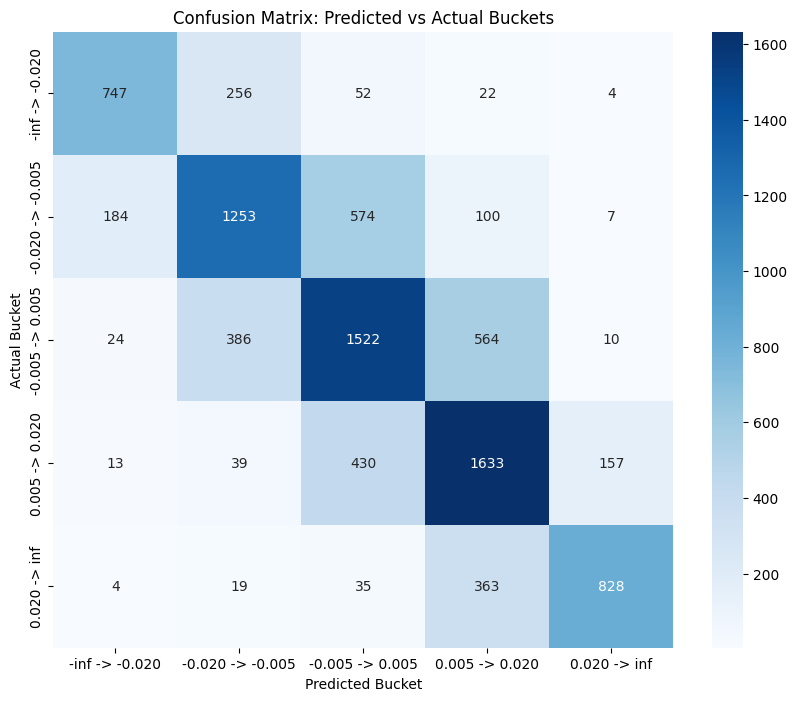

In [19]:
# 1. Get predictions (shape: Samples, 7, 7)
Y_msft_pred = model.predict(X_msft_data)

# 2. Convert probabilities and true labels to integer classes
# We flatten them to treat every 'predicted day' as an individual sample
Y_msft_pred_classes = np.argmax(Y_msft_pred, axis=-1)[:, 0]
Y_msft_true_classes = np.argmax(Y_msft_data, axis=-1)[:, 0]

# 3. Generate Classification Report
# This shows Precision, Recall, and F1-Score for each of your 7 buckets
# bucket_names = ['Strong Down', 'Down', 'Slight Down', 'Flat', 'Slight Up', 'Up', 'Strong Up']
print("Classification Report:\n")
print(classification_report(Y_msft_true_classes, Y_msft_pred_classes, target_names=bucket_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(Y_msft_true_classes, Y_msft_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bucket_names, yticklabels=bucket_names)
plt.title('Confusion Matrix: Predicted vs Actual Buckets')
plt.ylabel('Actual Bucket')
plt.xlabel('Predicted Bucket')
plt.show()

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:

                  precision    recall  f1-score   support

  -inf -> -0.020       0.38      0.17      0.23      7563
-0.020 -> -0.005       0.44      0.12      0.19     14830
 -0.005 -> 0.005       0.44      0.13      0.20     17548
  0.005 -> 0.020       0.28      0.78      0.41     15904
    0.020 -> inf       0.33      0.29      0.31      8737

        accuracy                           0.31     64582
       macro avg       0.37      0.30      0.27     64582
    weighted avg       0.38      0.31      0.27     64582



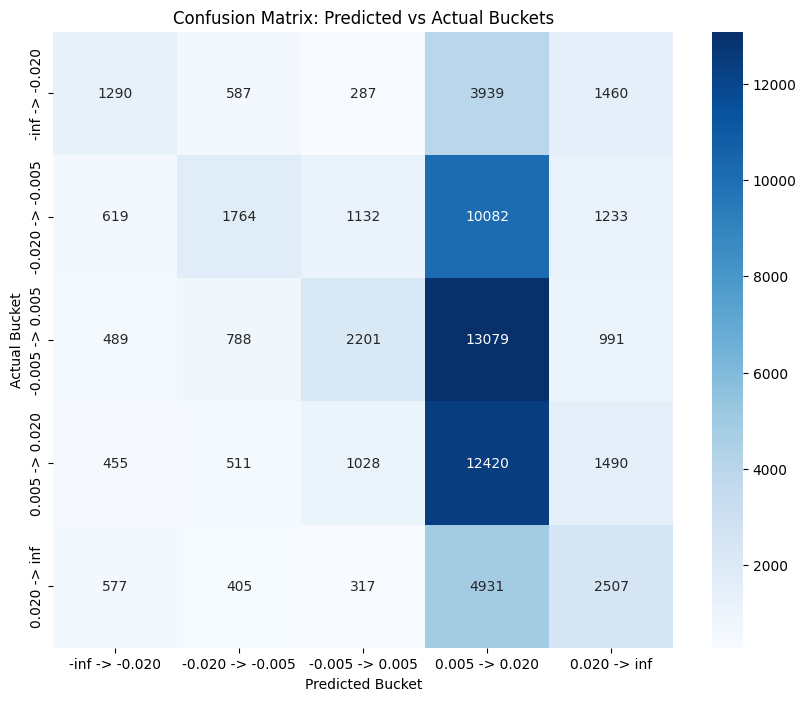

In [20]:
# 1. Get predictions (shape: Samples, 7, 7)
Y_msft_pred = model.predict(X_msft_data)

# 2. Convert probabilities and true labels to integer classes
# We flatten them to treat every 'predicted day' as an individual sample
Y_msft_pred_classes = np.argmax(Y_msft_pred, axis=-1).flatten()
Y_msft_true_classes = np.argmax(Y_msft_data, axis=-1).flatten()

# 3. Generate Classification Report
# This shows Precision, Recall, and F1-Score for each of your 7 buckets
# bucket_names = ['Strong Down', 'Down', 'Slight Down', 'Flat', 'Slight Up', 'Up', 'Strong Up']
print("Classification Report:\n")
print(classification_report(Y_msft_true_classes, Y_msft_pred_classes, target_names=bucket_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(Y_msft_true_classes, Y_msft_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bucket_names, yticklabels=bucket_names)
plt.title('Confusion Matrix: Predicted vs Actual Buckets')
plt.ylabel('Actual Bucket')
plt.xlabel('Predicted Bucket')
plt.show()

In [21]:
data_acb.head()

,low,high,open,close,volume,year,days,month_sin,month_cos,day_sin,day_cos,weekday_sin,weekday_cos
0,0.088439,-0.046358,0.178685,0.033976,0.097721,0.6,0.604785,-0.5,0.866025,-0.968077,-0.250653,0.433884,-0.900969
1,0.000000,0.012390,0.009068,0.027085,0.115104,0.6,0.604830,-0.5,0.866025,-0.998717,-0.050649,-0.433884,-0.900969
2,0.074118,0.047239,-0.027454,0.058912,-0.094452,0.6,0.604875,-0.5,0.866025,-0.988468,0.151428,-0.974928,-0.222521
3,-0.036440,0.060004,0.045346,0.000000,-0.405465,0.6,0.605009,-0.5,0.866025,-0.724793,0.688967,0.781831,0.623490
4,0.036440,-0.073275,0.017578,-0.024752,-0.761466,0.6,0.605054,-0.5,0.866025,-0.571268,0.820763,0.974928,-0.222521


In [22]:
data_acb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4051 entries, 0 to 4050
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   low          4051 non-null   float64
 1   high         4051 non-null   float64
 2   open         4051 non-null   float64
 3   close        4051 non-null   float64
 4   volume       4051 non-null   float64
 5   year         4051 non-null   float64
 6   days         4051 non-null   float64
 7   month_sin    4051 non-null   float64
 8   month_cos    4051 non-null   float64
 9   day_sin      4051 non-null   float64
 10  day_cos      4051 non-null   float64
 11  weekday_sin  4051 non-null   float64
 12  weekday_cos  4051 non-null   float64
dtypes: float64(13)
memory usage: 411.6 KB


In [23]:
# Split the dataset into time windows to get data samples.

acb_scale_factor = scale_factor
df_acb = (
    data_acb.clip(-1, 1)  # First clip (original range)
    .assign(**{c: lambda d, c=c: d[c] * acb_scale_factor for c in cols_to_scale}) # Multiply
    .clip(-1, 1)  # Final output clip
)

X_acb_data = []
Y_acb_data = []
for i in range(len(df_acb) - window_input - window_output):
    data_input = df_acb.iloc[i : i + window_input].values
    raw_y = df_acb.iloc[i + window_input : i + window_input + window_output, 2].values
    bucketed = np.digitize(raw_y, thresholds)
    data_output = keras.utils.to_categorical(bucketed, num_classes=n_classes)
    X_acb_data.append(data_input)
    Y_acb_data.append(data_output)

X_acb_data = np.array(X_acb_data)
Y_acb_data = np.array(Y_acb_data)

print(f"X shape: {X_acb_data.shape}")
print(f"Y shape: {Y_acb_data.shape}")

X shape: (4014, 30, 13)
Y shape: (4014, 7, 5)


126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:

                  precision    recall  f1-score   support

  -inf -> -0.020       0.81      0.58      0.68       569
-0.020 -> -0.005       0.60      0.54      0.57       922
 -0.005 -> 0.005       0.55      0.61      0.58      1092
  0.005 -> 0.020       0.53      0.70      0.61       820
    0.020 -> inf       0.81      0.64      0.72       611

        accuracy                           0.61      4014
       macro avg       0.66      0.61      0.63      4014
    weighted avg       0.63      0.61      0.62      4014



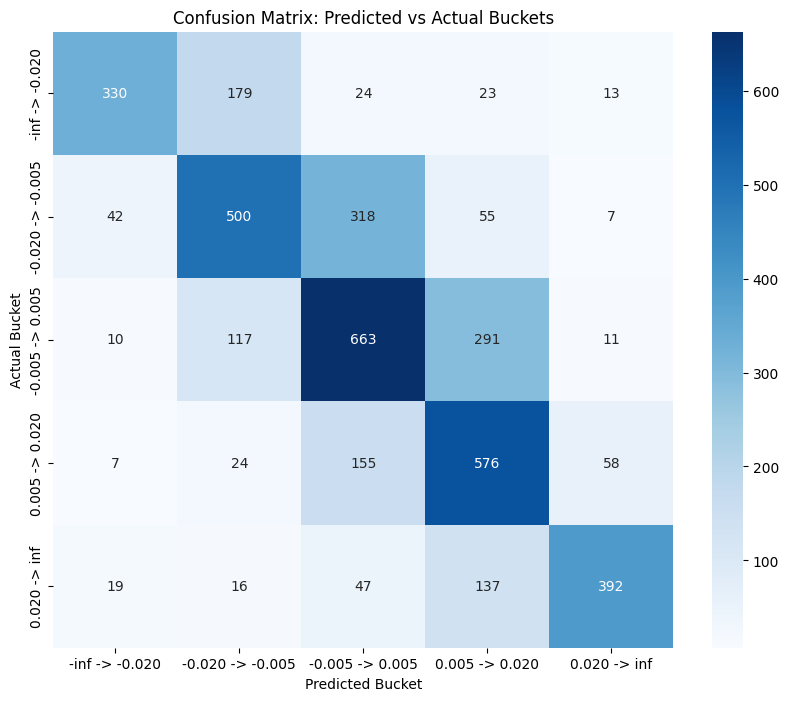

In [31]:
# 1. Get predictions (shape: Samples, 7, 7)
Y_acb_pred = model.predict(X_acb_data)

# 2. Convert probabilities and true labels to integer classes
# We flatten them to treat every 'predicted day' as an individual sample
Y_acb_pred_classes = np.argmax(Y_acb_pred, axis=-1)[:, 0]
Y_acb_true_classes = np.argmax(Y_acb_data, axis=-1)[:, 0]

# 3. Generate Classification Report
# This shows Precision, Recall, and F1-Score for each of your 7 buckets
# bucket_names = ['Strong Down', 'Down', 'Slight Down', 'Flat', 'Slight Up', 'Up', 'Strong Up']
print("Classification Report:\n")
print(classification_report(Y_acb_true_classes, Y_acb_pred_classes, target_names=bucket_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(Y_acb_true_classes, Y_acb_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bucket_names, yticklabels=bucket_names)
plt.title('Confusion Matrix: Predicted vs Actual Buckets')
plt.ylabel('Actual Bucket')
plt.xlabel('Predicted Bucket')
plt.show()

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:

                  precision    recall  f1-score   support

  -inf -> -0.020       0.35      0.22      0.27      3988
-0.020 -> -0.005       0.41      0.10      0.16      6463
 -0.005 -> 0.005       0.47      0.10      0.16      7639
  0.005 -> 0.020       0.24      0.75      0.36      5732
    0.020 -> inf       0.32      0.36      0.34      4276

        accuracy                           0.29     28098
       macro avg       0.36      0.30      0.26     28098
    weighted avg       0.37      0.29      0.24     28098



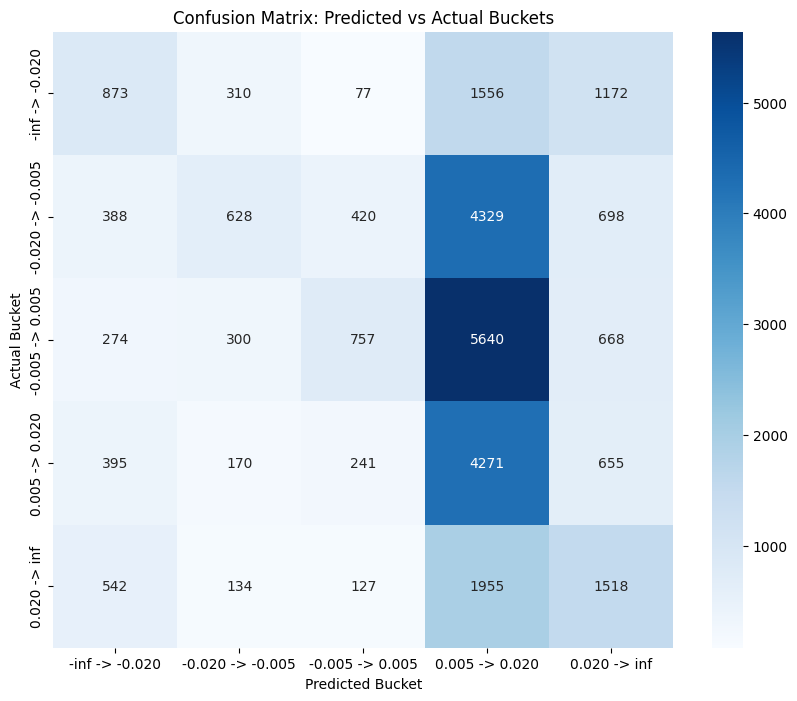

In [30]:
# 1. Get predictions (shape: Samples, 7, 7)
Y_acb_pred = model.predict(X_acb_data)

# 2. Convert probabilities and true labels to integer classes
# We flatten them to treat every 'predicted day' as an individual sample
Y_acb_pred_classes = np.argmax(Y_acb_pred, axis=-1).flatten()
Y_acb_true_classes = np.argmax(Y_acb_data, axis=-1).flatten()

# 3. Generate Classification Report
# This shows Precision, Recall, and F1-Score for each of your 7 buckets
# bucket_names = ['Strong Down', 'Down', 'Slight Down', 'Flat', 'Slight Up', 'Up', 'Strong Up']
print("Classification Report:\n")
print(classification_report(Y_acb_true_classes, Y_acb_pred_classes, target_names=bucket_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(Y_acb_true_classes, Y_acb_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=bucket_names, yticklabels=bucket_names)
plt.title('Confusion Matrix: Predicted vs Actual Buckets')
plt.ylabel('Actual Bucket')
plt.xlabel('Predicted Bucket')
plt.show()

In [32]:
model.save("model_appl_trained.keras")